In [25]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


### Load and Explore the Dataset

In [26]:
df = pd.read_csv('Downloads/advertise.csv')

In [27]:
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [28]:
df.shape

(4572, 4)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [30]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [31]:
df.duplicated().sum()

np.int64(0)

### Handle Missing Values

In [32]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [33]:
df['TV'] = df['TV'].fillna(df['TV'].median())
df['Radio'] = df['Radio'].fillna(df['TV'].median())
df['Social_Media'] = df['Social_Media'].fillna(df['Social_Media'].median())
df['Sales'] = df['Sales'].fillna(df['Sales'].median())

In [34]:
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

### Exploratory Data Analysis

In [35]:
df['TV'].value_counts()

TV
43.0    70
40.0    67
34.0    65
47.0    65
21.0    64
        ..
76.0    36
81.0    36
91.0    34
71.0    32
57.0    31
Name: count, Length: 91, dtype: int64

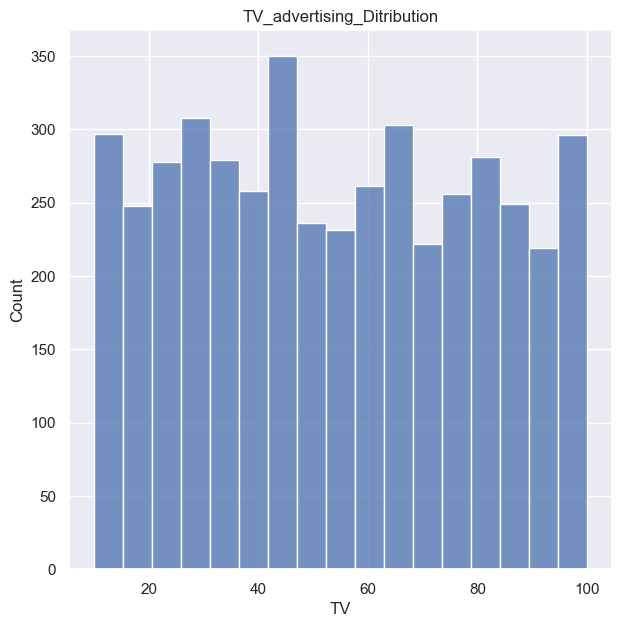

In [36]:
sns.set()
plt.figure(figsize=(7,7))
sns.histplot(df['TV'])
plt.title('TV_advertising_Ditribution')
plt.show()

In [37]:
df['Radio'].value_counts()

Radio
53.000000    4
16.266718    1
23.047709    1
5.266441     1
12.795500    1
            ..
10.297245    1
32.280814    1
30.511052    1
1.551591     1
15.966688    1
Name: count, Length: 4569, dtype: int64

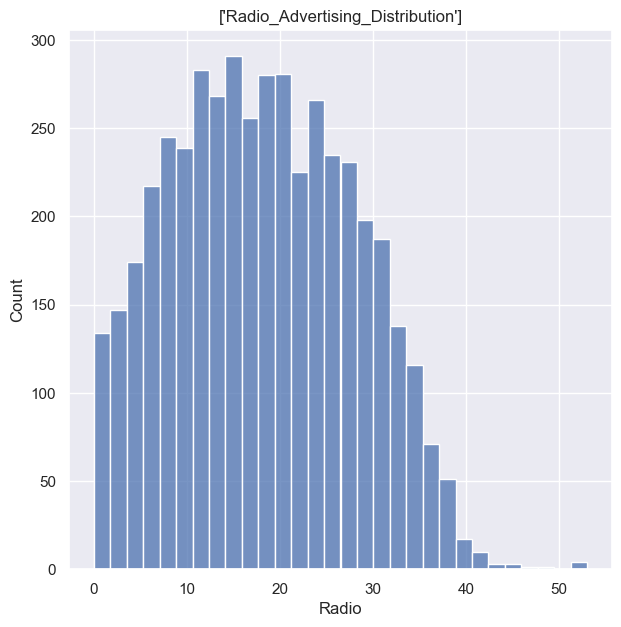

In [38]:
plt.figure(figsize= (7,7))
sns.histplot(df['Radio'])
plt.title(['Radio_Advertising_Distribution'])
plt.show()

In [39]:
df['Social_Media'].value_counts()

Social_Media
3.055565    6
2.907983    1
3.204359    1
1.465807    1
1.353229    1
           ..
4.606428    1
2.625733    1
0.486129    1
5.834040    1
5.046548    1
Name: count, Length: 4567, dtype: int64

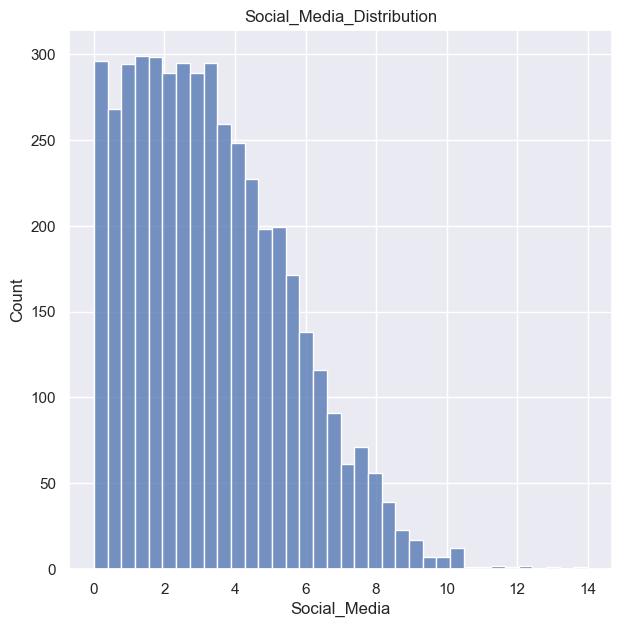

In [40]:
plt.figure(figsize=(7,7))
sns.histplot(df['Social_Media'])
plt.title('Social_Media_Distribution')
plt.show()

In [41]:
df['Sales'].value_counts()

Sales
189.231172    6
54.732757     1
117.047403    1
194.961033    1
208.882578    1
             ..
311.433546    1
232.994852    1
80.973457     1
308.059846    1
148.202414    1
Name: count, Length: 4567, dtype: int64

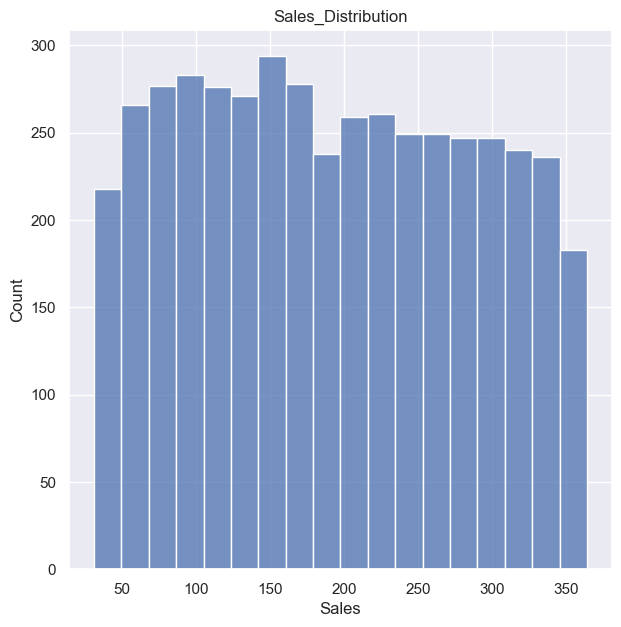

In [42]:
plt.figure(figsize=(7,7))
sns.histplot(df['Sales'])
plt.title('Sales_Distribution')
plt.show()

### independent variable (TV, Radio, or Social Media) most correlated with Sales using correlation matrix

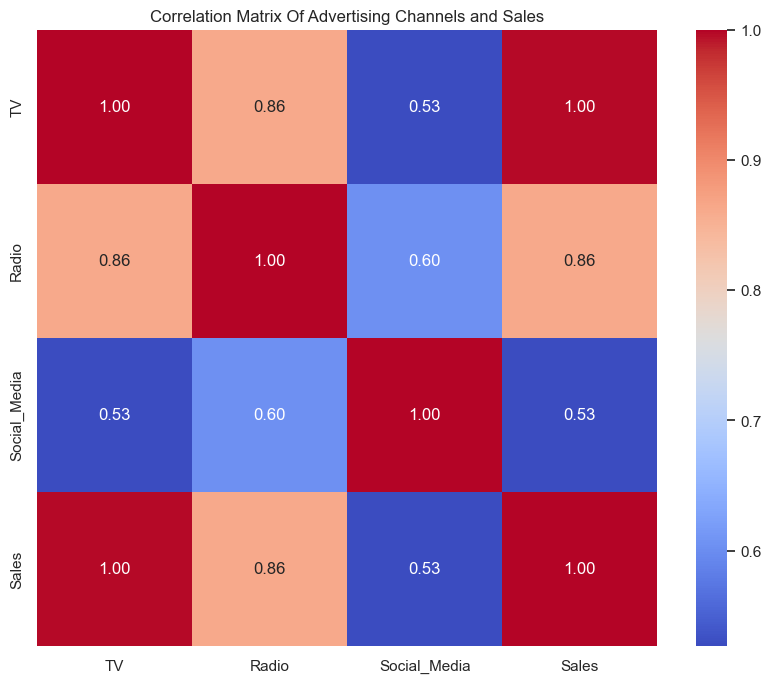

In [43]:
correlation_matrix = df.corr()
plt.figure(figsize=(10,8))
plt.title('Correlation Matrix Of Advertising Channels and Sales')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

TV and Sales (0.9976): There is a very strong positive correlation between TV advertising spend and Sales. This indicates that as TV advertising increases, Sales tend to increase significantly.

Radio and Sales (0.8683): There is a strong positive correlation between Radio advertising spend and Sales. This means that an increase in Radio advertising is also associated with a substantial increase in Sales.

Social_Media and Sales (0.5286): There is a moderate positive correlation between Social Media advertising spend and Sales. While still positive, the relationship is not as strong as with TV or Radio, suggesting a less direct or pronounced impact on Sales.


### Visualizing The Relationship Between The Independent Variables and The Dependent Variable

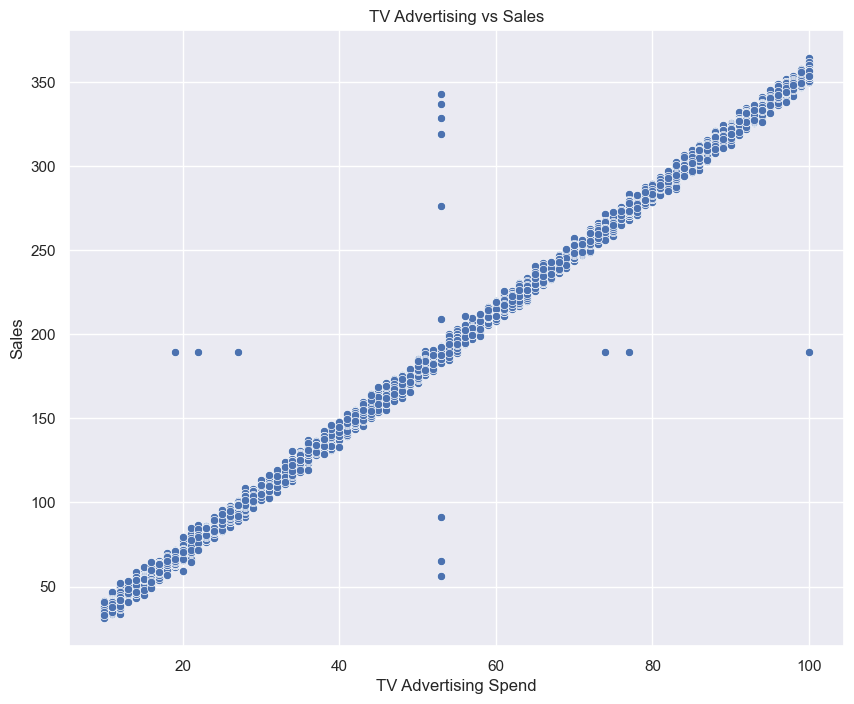

In [44]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='TV', y='Sales', data=df)
plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

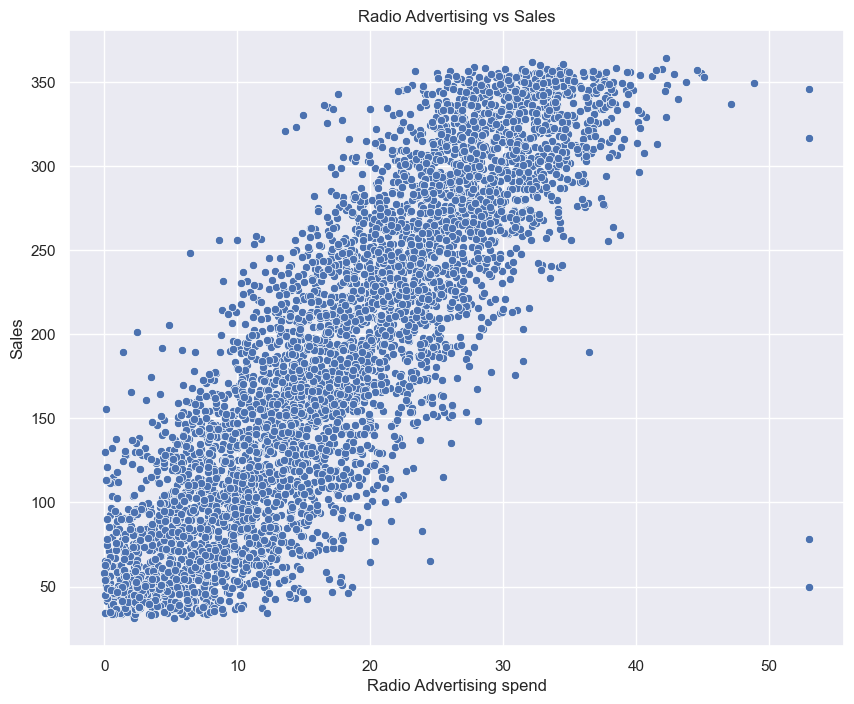

In [45]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.title('Radio Advertising vs Sales')
plt.xlabel('Radio Advertising spend')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

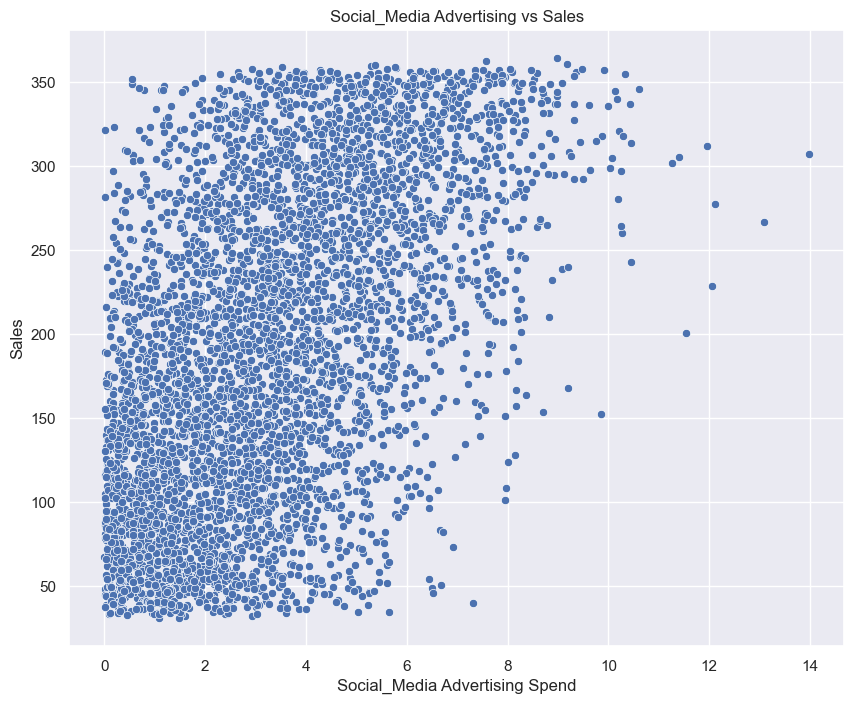

In [46]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Social_Media', y='Sales', data=df)
plt.title('Social_Media Advertising vs Sales')
plt.xlabel('Social_Media Advertising Spend')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

#### The scatter plots visually represent the relationship between each advertising channel and Sales.

##### TV vs. Sales:

The scatter plot for TV advertising and Sales likely shows a strong, clear upward trend, indicating a very strong positive linear relationship. As TV advertising spend increases, Sales tend to increase significantly and consistently.

##### Radio vs. Sales:

The scatter plot for Radio advertising and Sales should also display a positive trend, though perhaps with a bit more scatter than TV, suggesting a strong positive linear relationship. As Radio advertising spend increases, Sales also tend to increase.

##### Social Media vs. Sales: 

The scatter plot for Social Media advertising and Sales will probably show a more spread-out pattern compared to TV and Radio, indicating a moderate positive relationship. While there's an upward trend, the data points are less tightly clustered around a line, implying that Social Media has a positive but less consistent or weaker impact on Sales compared to the other channels.

These visual interpretations align with the correlation coefficients calculated in the heatmap: TV having the strongest positive correlation, followed by Radio, and then Social Media.

### Building a Simple Linear Regression Model

In [47]:
import statsmodels.api as sm

x = df['TV']
y = df['Sales']

X = sm.add_constant(x)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 6.759e+05
Date:                Fri, 12 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:24:16   Log-Likelihood:                -15776.
No. Observations:                4572   AIC:                         3.156e+04
Df Residuals:                    4570   BIC:                         3.157e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2923      0.260      1.126      0.2

### Interpretation Of Diagnostic Plots

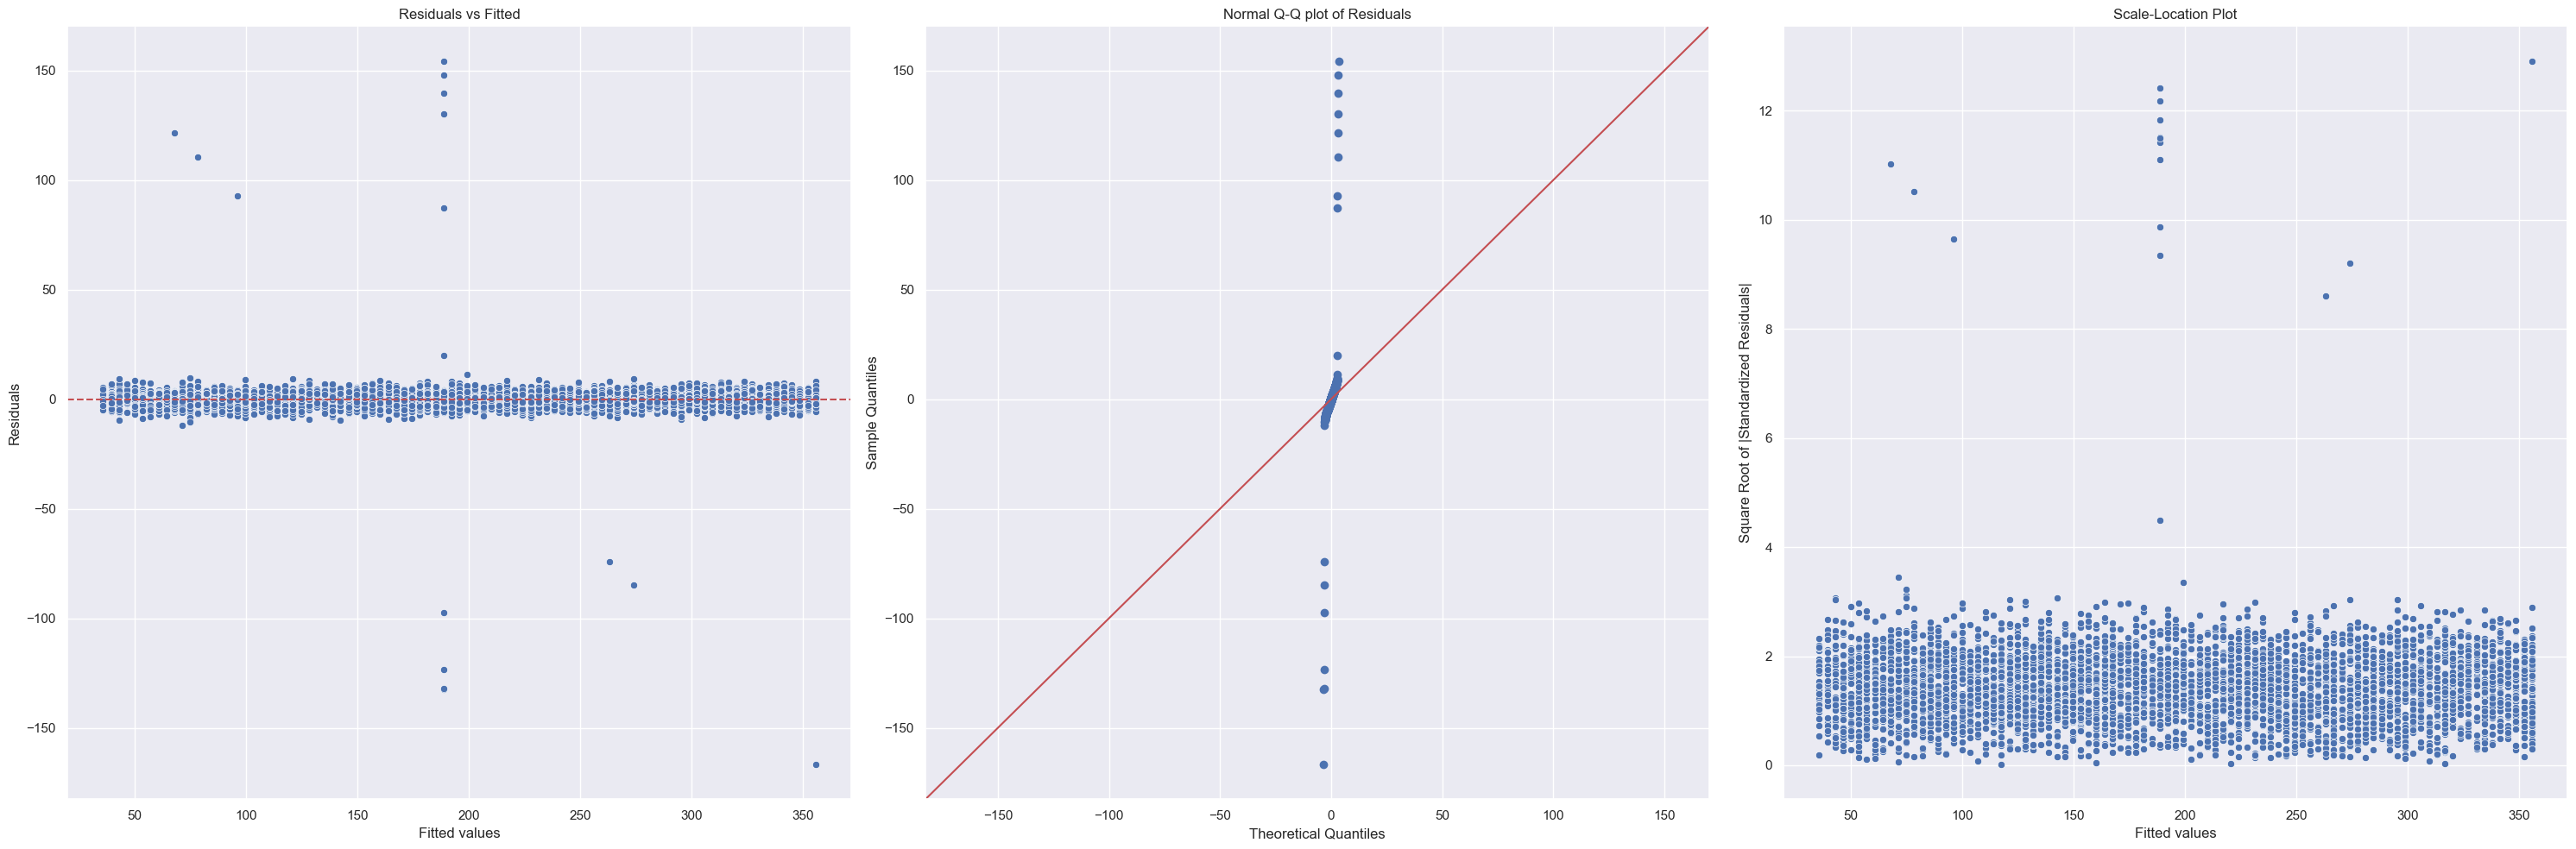

In [48]:
import statsmodels.api as sm
import scipy.stats as stats

# Get predictions and residuals
y_pred = model.predict(X)
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

# Plot 1: Residuals vs Fitted values (Linearity and Homoscedasticity)
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Plot 2: Normal Q-Q plot (Normality of Residuals)
sm.qqplot(residuals, line='45', ax=axes[1])
axes[1].set_title('Normal Q-Q plot of Residuals')

# Plot 3: Scale-Location plot (Homoscedasticity)
sqrt_abs_residuals = np.sqrt(np.abs(residuals))
sns.scatterplot(x=y_pred, y=sqrt_abs_residuals, ax=axes[2])
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Square Root of |Standardized Residuals|')
axes[2].set_title('Scale-Location Plot')

plt.tight_layout()
plt.show()

##### Residuals vs Fitted Plot (Linearity and Homoscedasticity)

    Interpretation: Observing this plot, the residuals appear to be largely scattered randomly around the horizontal line at zero.
    
    There isnt a clear pattern or curve, which generally supports the assumption of linearity. The spread of the residuals also seems fairly consistent across the range of fitted values. There are no obvious funnel shapes, indicating that the assumption of homoscedasticity is reasonably met.

##### Normal Q-Q Plot of Residuals (Normality):

    Interpretation: In the Normal Q-Q plot, most of the data points closely follow the 45-degree reference line. There might be some minor deviations at the extreme ends (tails), which is common in real-world data, but overall, it suggests that the residuals are approximately normally distributed. This supports the normality assumption for the residuals.

##### Scale-Location Plot (Homoscedasticity):

    Interpretation: This plot also reinforces the observation from the Residuals vs Fitted plot regarding homoscedasticity. The points appear to be randomly scattered, and there isn't a noticeable trend (increasing or decreasing spread) as the fitted values change. This further confirms that the variance of the residuals is relatively constant, supporting the assumption of homoscedasticity.

In summary, based on these diagnostic plots, the key assumptions of linearity, normality of residuals, and homoscedasticity for our Simple Linear Regression model appear to be reasonably satisfied. This increases our confidence in the validity and reliability of the model's results.


In summary, TV advertising has the strongest linear relationship with Sales, followed by Radio, and then Social Media.


### Interpreting R-squared, coefficients, and p-values in business context

To interpret the results of our Simple Linear Regression model for 'Sales' based on 'TV' advertising:

##### R-squared (0.993): 

This indicates that approximately 99.3% of the variation in 'Sales' can be explained by the variation in 'TV' advertising spend. This is an extremely high R-squared value, suggesting that TV advertising is a very strong predictor of Sales.
In a business context, this means that changes in TV ad spend are very closely linked to changes in sales.

##### Coefficient for TV (3.5545):

This is the most crucial part for business insights. It means that for every one-unit increase in 'TV' advertising spend, 'Sales' are predicted to increase by 3.5545 units, assuming all other factors remain constant. If our units are in, say, thousands of dollars for TV spend and thousands of items for sales, then spending an additional $1,000 on TV advertising is associated with an increase of 3,554.5 units in sales.

##### P-value for TV (0.000):

The p-value for the 'TV' coefficient is 0.000, which is much less than the conventional significance level of 0.05. This means that the coefficient for 'TV' is statistically significant. In business terms, this tells us with high confidence that there is a real relationship between TV advertising and sales, and the observed effect is not due to random chance.

##### Coefficient for const (0.2804): 

This is the intercept. It suggests that when 'TV' advertising spend is zero, the predicted 'Sales' would be approximately 0.2804 units. While statistically significant (p-value 0.279, which is greater than 0.05, so not statistically significant in this case), the intercept itself is often less interpretable in a business context if a zero advertising spend scenario is unrealistic or if the model is not intended to extrapolate to such extremes.


### ROI-based Recommendation for Marketing Budget Allocation


Our Simple Linear Regression model demonstrates an extremely strong positive relationship between TV advertising spend and Sales. The key takeaway from the model summary is the coefficient for TV, which is 3.5545.

#### Interpretation of ROI:

This coefficient implies that for every one unit increase in TV advertising expenditure, we can expect Sales to increase by approximately 3.5545 units. If we assume that both "TV" spend and "Sales" are measured in the same monetary units (e.g., thousands of dollars), this translates directly into a robust Return on. 

#### Investment (ROI):

    - For every 1 invested in TV advertising, 3.5545 in sales revenue is generated.
    
    - The Net Return on Investment (ROI) = (Generated Sales - Investment) / Investment = (3.5545−1) / $1 = 2.5545 or 255.45%.

This is an exceptionally high ROI, indicating that TV advertising is a highly effective and profitable channel for driving sales.

#### Recommendation:

Given the statistically significant and substantial impact of TV advertising on Sales, along with a very high R-squared value (0.993) indicating the model's strong explanatory power, the primary recommendation for marketing budget allocation is to prioritize and significantly increase investment in TV advertising.

While Radio and Social Media also show positive correlations with Sales, their impact is less pronounced compared to TV. Therefore, for optimizing sales growth and maximizing ROI, TV advertising should be the cornerstone of the marketing strategy. Further analysis could explore the optimal saturation point for TV advertising or potential synergy effects when combined with other channels, but based on the current model, TV stands out as the most efficient sales driver.
